# Cell 1.1 (Code Cell): Load and Inspect the Dataset

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('D:/Machine Learning/Deep Learning/Pr 1/pr2/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Cell 1.2 (Code Cell): Handle Missing Values

In [8]:
# Replace placeholder '?' with NaN and check missing values count
df.replace('?', np.nan, inplace=True)
print("Missing values per column:\n", df.isnull().sum())

# Drop rows containing any missing values
df.dropna(inplace=True)
print(f"Dataset shape after dropping missing values: {df.shape}")

Missing values per column:
 age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64
Dataset shape after dropping missing values: (45222, 15)


Cell 1.3 (Code Cell): Drop Redundant Columns

In [9]:
# Drop 'fnlwgt' (census sampling weight - not predictive) and 'education' (redundant with 'educational-num')
df.drop(columns=['fnlwgt', 'education'], inplace=True)

# Confirm final shape for Task 1 cleaning phase
print(f"Shape after dropping redundant columns: {df.shape}")

Shape after dropping redundant columns: (45222, 13)


Cell 1.4 (Code Cell): Encode the Target

income
0    34014
1    11208
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_32436\158567702.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='income', data=df, palette='Set2')


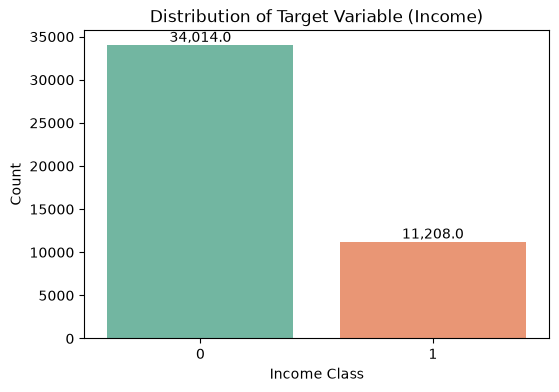

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert target income column into binary format (1 if '>50K', else 0)
df['income'] = (df['income'] == '>50K').astype(int)

# Check value counts
print(df['income'].value_counts())

# Plot countplot with annotations
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='income', data=df, palette='Set2')
plt.title('Distribution of Target Variable (Income)')
plt.xlabel('Income Class')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

Cell 1.5 (Code Cell): Exploratory Visualisations

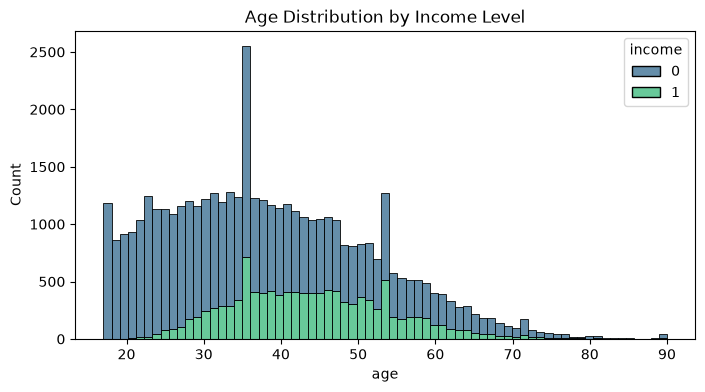

In [11]:
# (a) Histplot of 'age' colored by 'income'
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', hue='income', multiple='stack', palette='viridis')
plt.title('Age Distribution by Income Level')
plt.show()

1.6 (Code Cell): Encode Categoricals & Scale Numerics

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('income', axis=1)
y = df['income']

# One-hot encode categorical features (drop_first=True to avoid collinearity)
X = pd.get_dummies(X, drop_first=True)
print(f"Shape after One-Hot Encoding: {X.shape}")

# Identify numeric columns for scaling
numeric_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Train-test split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply StandardScaler ONLY to numeric columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Confirm split shapes and class ratio preservation
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print("Train target class distribution:\n", y_train.value_counts(normalize=True))
print("Test target class distribution:\n", y_test.value_counts(normalize=True))

Shape after One-Hot Encoding: (45222, 80)
X_train shape: (36177, 80), X_test shape: (9045, 80)
Train target class distribution:
 income
0    0.752163
1    0.247837
Name: proportion, dtype: float64
Test target class distribution:
 income
0    0.752128
1    0.247872
Name: proportion, dtype: float64


# 2.1 (Code Cell): Define the Reusable build_ann() Function

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

def build_ann(input_dim, hidden_units=[128, 64], activation='relu', 
              initializer='glorot_uniform', use_batch_norm=False, 
              optimizer='adam', loss='binary_crossentropy'):
    """
    Constructs and compiles a configurable Multi-Layer Perceptron (ANN) model.
    Enables controlled experimentation by changing single parameters at a time.
    """
    model = Sequential()
    
    # Input layer and first hidden layer
    model.add(Dense(hidden_units[0], input_dim=input_dim, 
                    activation=activation, kernel_initializer=initializer))
    if use_batch_norm:
        model.add(BatchNormalization())
        
    # Subsequent hidden layers
    for units in hidden_units[1:]:
        model.add(Dense(units, activation=activation, kernel_initializer=initializer))
        if use_batch_norm:
            model.add(BatchNormalization())
            
    # Output layer for binary classification
    model.add(Dense(1, activation='sigmoid', kernel_initializer=initializer))
    
    # Compile the model
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    
    return model

2.2 (Code Cell): Baseline ANN Architecture & Summary

In [14]:
# Build the baseline model using default configuration
input_dim = X_train.shape[1]
model_base = build_ann(input_dim=input_dim)

# Print model summary to inspect layers and parameter counts
model_base.summary()

d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

2.3 (Code Cell): Train the Baseline Model

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8417 - loss: 0.3367 - val_accuracy: 0.8530 - val_loss: 0.3221
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8516 - loss: 0.3149 - val_accuracy: 0.8532 - val_loss: 0.3228
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8538 - loss: 0.3112 - val_accuracy: 0.8527 - val_loss: 0.3204
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8555 - loss: 0.3081 - val_accuracy: 0.8546 - val_loss: 0.3205
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8558 - loss: 0.3052 - val_accuracy: 0.8507 - val_loss: 0.3212
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8592 - loss: 0.3033 - val_accuracy: 0.8502 - val_loss: 0.3196
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8596 - loss: 0.3006 - val_accuracy: 0.8546 - val_loss: 0.3204
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8611 - loss: 0.2983 - val_accuracy: 0.

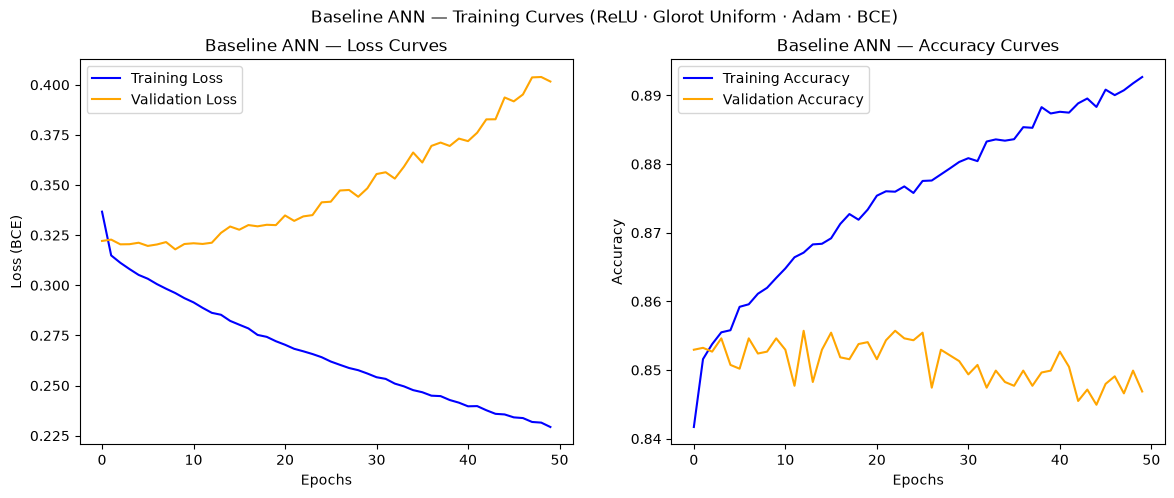

In [15]:
import matplotlib.pyplot as plt

# Train the baseline model for 50 epochs with a validation split of 10%
history_base = model_base.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

# Plot training vs validation loss and accuracy as a 1x2 subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss subplot
ax1.plot(history_base.history['loss'], label='Training Loss', color='blue')
ax1.plot(history_base.history['val_loss'], label='Validation Loss', color='orange')
ax1.set_title('Baseline ANN — Loss Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (BCE)')
ax1.legend()

# Accuracy subplot
ax2.plot(history_base.history['accuracy'], label='Training Accuracy', color='blue')
ax2.plot(history_base.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax2.set_title('Baseline ANN — Accuracy Curves')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Baseline ANN — Training Curves (ReLU · Glorot Uniform · Adam · BCE)')
plt.show()

2.4 (Code Cell): Evaluate the Baseline with Full Metrics

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.91      0.89      6803
        >50K       0.69      0.63      0.66      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.77      0.78      9045
weighted avg       0.83      0.84      0.84      9045



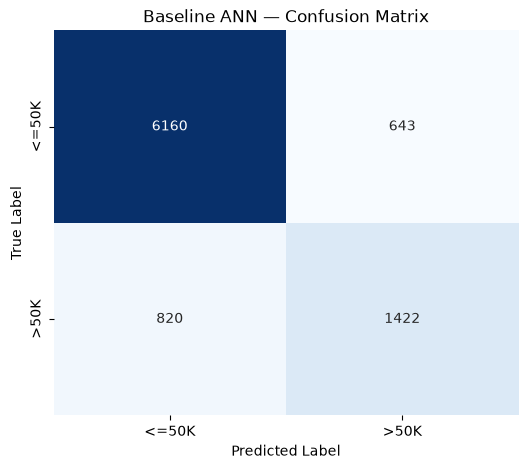

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predicted probabilities and convert to binary classes (threshold = 0.5)
y_pred_prob = model_base.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Baseline ANN — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

3.1 (Code Cell): Train 4 Models with Different Hidden Activations

In [18]:
# Train 4 separate models using different activation functions with 50 epochs each
activations = ['relu', 'tanh', 'sigmoid', 'elu']
histories = {}
models = {}

for act in activations:
    print(f"Training model with activation: {act}")
    # Call build_ann function defined in Task 2
    model = build_ann(input_dim=X_train.shape[1], activation=act)
    
    history = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=64, 
        validation_split=0.1, 
        verbose=0
    )
    
    models[act] = model
    histories[act] = history

# Assign specific history objects as requested
history_relu = histories['relu']
history_tanh = histories['tanh']
history_sigmoid = histories['sigmoid']
history_elu = histories['elu']
print("All 4 activation models trained successfully!")

Training model with activation: relu


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with activation: tanh


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with activation: sigmoid


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with activation: elu


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


All 4 activation models trained successfully!


3.2 (Code Cell): Activation Comparison — 4-Panel Plot

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


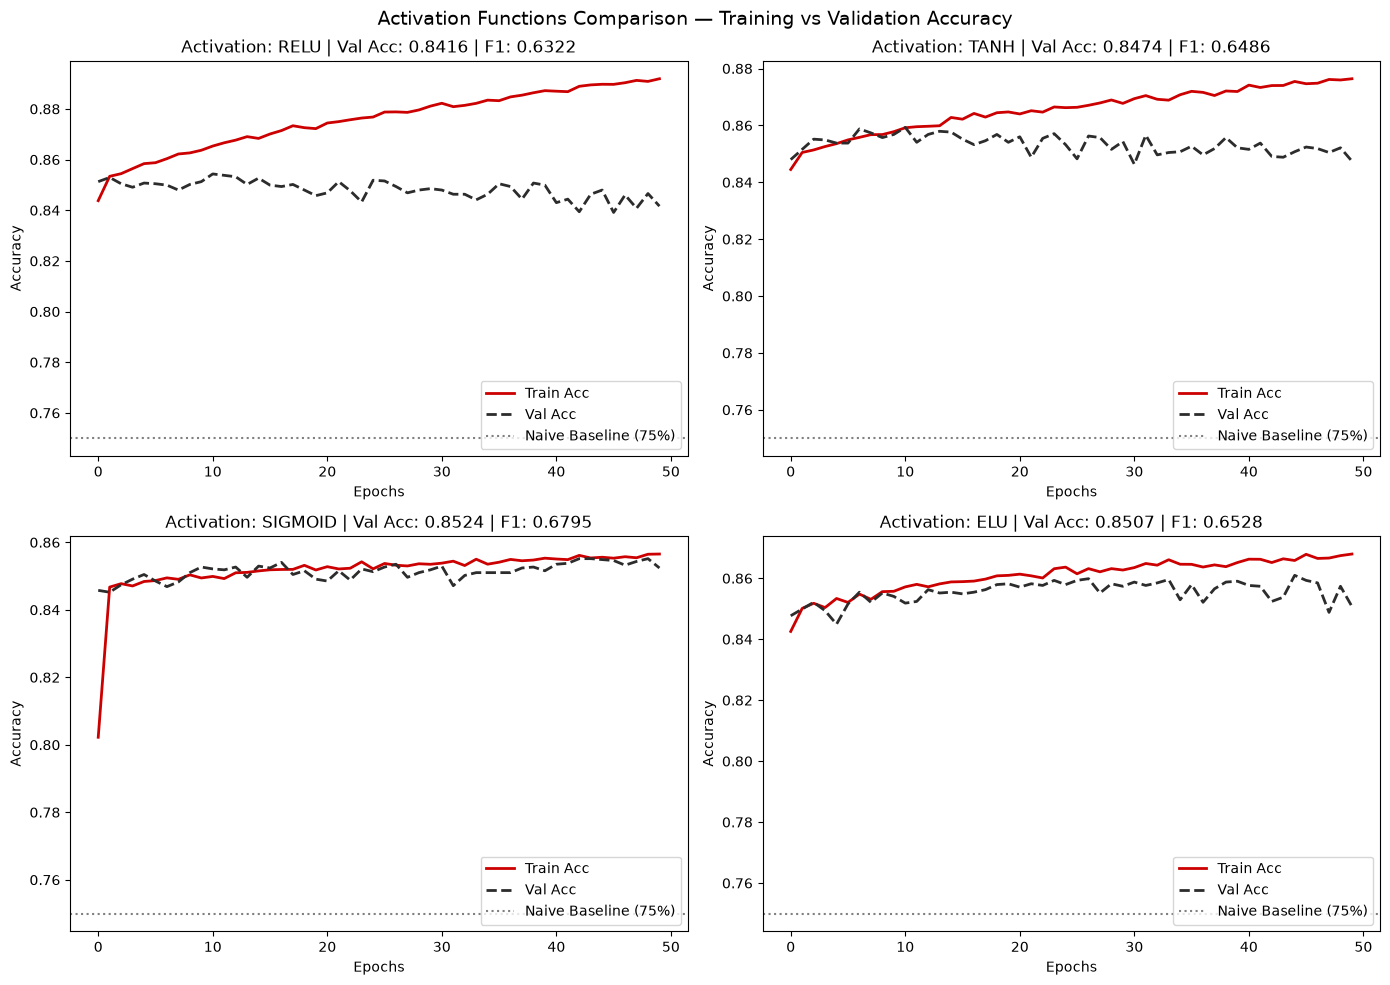

In [19]:
from sklearn.metrics import f1_score
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, act in enumerate(activations):
    ax = axes[idx]
    hist = histories[act]
    
    # Compute final validation accuracy and class 1 F1-score for annotation
    model = models[act]
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    val_acc = hist.history['val_accuracy'][-1]
    f1_class1 = f1_score(y_test, y_pred)
    
    # Plot training (Red #CC0000) vs validation (Charcoal #2C2C2C) accuracy curves
    ax.plot(hist.history['accuracy'], label='Train Acc', color='#CC0000', linewidth=2)
    ax.plot(hist.history['val_accuracy'], label='Val Acc', color='#2C2C2C', linewidth=2, linestyle='--')
    
    # Horizontal dashed line at 75% accuracy (naive majority-class baseline)
    ax.axhline(y=0.75, color='gray', linestyle=':', label='Naive Baseline (75%)')
    
    ax.set_title(f"Activation: {act.upper()} | Val Acc: {val_acc:.4f} | F1: {f1_class1:.4f}")
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')

plt.suptitle('Activation Functions Comparison — Training vs Validation Accuracy', fontsize=14)
plt.tight_layout()
plt.show()

3.3 (Code Cell): Dead Neuron Check — ReLU

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Fraction of dead neurons in first ReLU layer: 0.0000


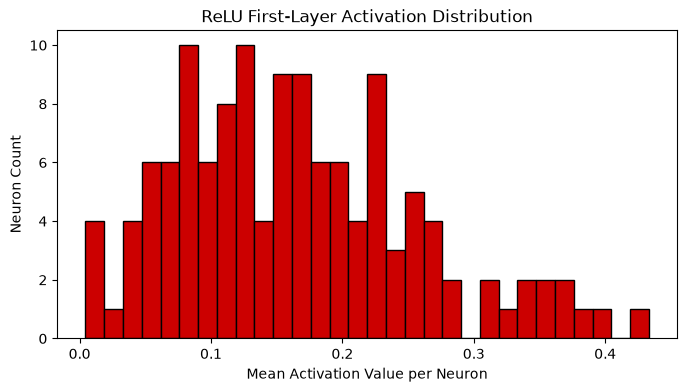

In [23]:
import tensorflow as tf


# Extract post-activation outputs of the first hidden layer for 500 test samples using a Keras sub-model
model_relu = models['relu']

# Fix for Keras 3: Use model.inputs instead of model.input to avoid AttributeError
intermediate = tf.keras.Model(
    inputs=model_relu.inputs, 
    outputs=model_relu.layers[0].output
)
layer_activations = intermediate.predict(X_test[:500])

# Compute dead neuron fraction (neurons with 0 activation across all samples)
dead_fraction = np.mean(np.all(layer_activations == 0, axis=0))
print(f"Fraction of dead neurons in first ReLU layer: {dead_fraction:.4f}")

# Plot histogram of mean activation per neuron
mean_activations = np.mean(layer_activations, axis=0)
plt.figure(figsize=(8, 4))
plt.hist(mean_activations, bins=30, color='#CC0000', edgecolor='black')
plt.title('ReLU First-Layer Activation Distribution')
plt.xlabel('Mean Activation Value per Neuron')
plt.ylabel('Neuron Count')
plt.show()

3.4 (Code Cell): Gradient Flow Check — Sigmoid Hidden Layers

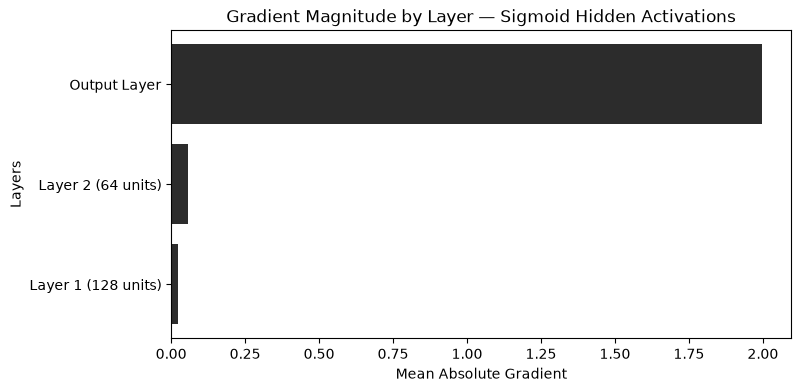

In [25]:
model_sigmoid = models['sigmoid']

# Prepare a single batch of data
X_batch = tf.convert_to_tensor(X_test[:64], dtype=tf.float32)
# Fix: Reshape y_batch to match preds shape (64, 1) to avoid rank mismatch error
y_batch = tf.convert_to_tensor(y_test[:64].values, dtype=tf.float32)
y_batch = tf.reshape(y_batch, (-1, 1))

with tf.GradientTape() as tape:
    preds = model_sigmoid(X_batch, training=True)
    loss_value = tf.keras.losses.binary_crossentropy(y_batch, preds)

# Extract gradients for Dense layers
dense_layers = [layer for layer in model_sigmoid.layers if isinstance(layer, tf.keras.layers.Dense)]
grads = tape.gradient(loss_value, [layer.kernel for layer in dense_layers])

mean_grads = [np.mean(np.abs(g.numpy())) for g in grads]
layer_names = [f"Layer {i+1} ({l.units} units)" for i, l in enumerate(dense_layers)]
layer_names[-1] = "Output Layer"

# Plot horizontal bar chart of mean absolute gradients
plt.figure(figsize=(8, 4))
plt.barh(layer_names, mean_grads, color='#2C2C2C')
plt.title('Gradient Magnitude by Layer — Sigmoid Hidden Activations')
plt.xlabel('Mean Absolute Gradient')
plt.ylabel('Layers')
plt.show()

4.1 (Code Cell): Train 5 Models with Different Initializers

In [26]:
# Train 5 separate models using different weight initializers with 50 epochs each
initializers = ['glorot_uniform', 'glorot_normal', 'he_uniform', 'he_normal', 'zeros']
init_histories = {}
init_models = {}

for init_name in initializers:
    print(f"Training model with initializer: {init_name}")
    # Call build_ann with activation='relu' and current initializer
    model = build_ann(input_dim=X_train.shape[1], activation='relu', initializer=init_name)
    
    history = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=64, 
        validation_split=0.1, 
        verbose=0
    )
    
    init_models[init_name] = model
    init_histories[init_name] = history

print("All 5 initialization models trained successfully!")

Training model with initializer: glorot_uniform


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with initializer: glorot_normal


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with initializer: he_uniform


...

Training model with initializer: he_normal


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with initializer: zeros


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


All 5 initialization models trained successfully!


Cell 4.2 (Markdown Cell): Why Initialization Matters

Why Initialization Matters:
Neural networks trained with all-zero weights suffer from the symmetry problem — every neuron in a layer produces the same output, receives the same gradient, and updates to the same value. The network collapses to a single effective neuron per layer regardless of width. Xavier/Glorot initialization draws weights from a distribution with $\text{Var} = 2/(\text{fan\_in} + \text{fan\_out})$, calibrated to keep the variance of activations and gradients stable across tanh/sigmoid layers. He initialization uses $\text{Var} = 2/\text{fan\_in}$ — the extra factor of 2 compensates for ReLU zeroing out half of all activations on average, maintaining the effective variance for ReLU networks.

4.3 (Code Cell): Convergence Speed Comparison Plot

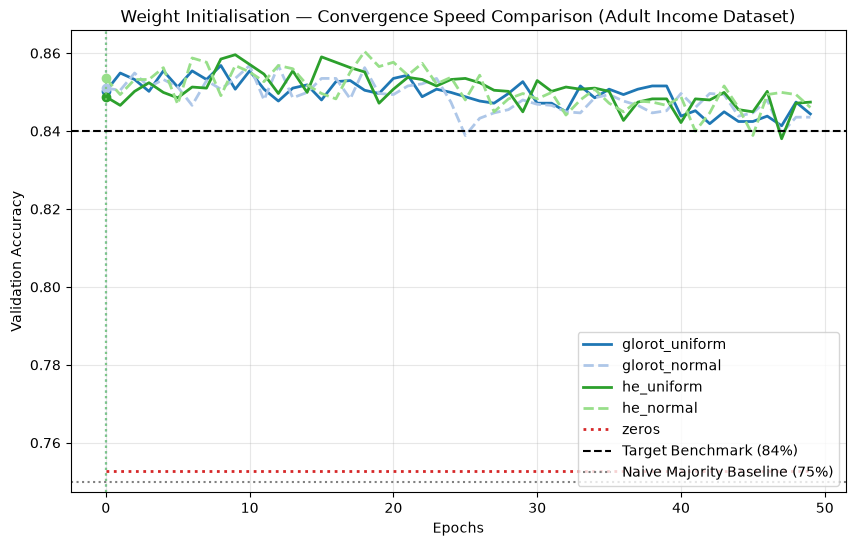

In [28]:
plt.figure(figsize=(10, 6))

colors = {'glorot_uniform': '#1f77b4', 'glorot_normal': '#aec7e8', 
          'he_uniform': '#2ca02c', 'he_normal': '#98df8a', 'zeros': '#d62728'}
linestyles = {'glorot_uniform': '-', 'glorot_normal': '--', 
              'he_uniform': '-', 'he_normal': '--', 'zeros': ':'}

for init_name, hist in init_histories.items():
    val_acc = hist.history['val_accuracy']
    plt.plot(val_acc, label=init_name, color=colors[init_name], linestyle=linestyles[init_name], linewidth=2)
    
    # Mark the first epoch each non-zeros model crossed 82% validation accuracy
    if init_name != 'zeros':
        crossed_epochs = [i for i, acc in enumerate(val_acc) if acc >= 0.82]
        if crossed_epochs:
            first_epoch = crossed_epochs[0]
            plt.axvline(x=first_epoch, color=colors[init_name], linestyle=':', alpha=0.5)
            plt.plot(first_epoch, val_acc[first_epoch], marker='o', color=colors[init_name])

# Horizontal dashed line at 84% target benchmark and 75% majority class
plt.axhline(y=0.84, color='black', linestyle='--', label='Target Benchmark (84%)')
plt.axhline(y=0.75, color='gray', linestyle=':', label='Naive Majority Baseline (75%)')

plt.title('Weight Initialisation — Convergence Speed Comparison (Adult Income Dataset)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

4.4 (Code Cell): Zeros Failure Demonstration

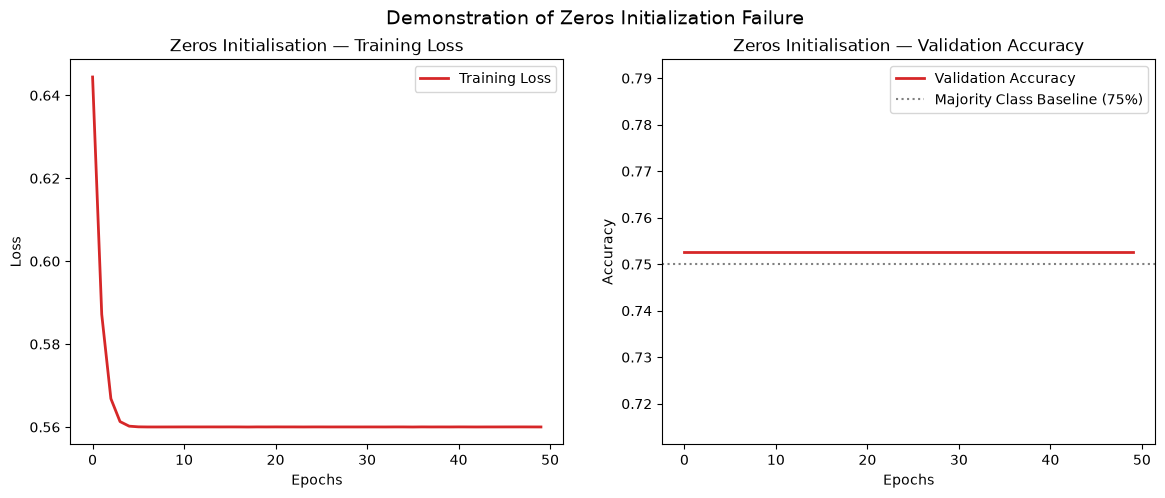

In [29]:
zeros_hist = init_histories['zeros']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss Curve
ax1.plot(zeros_hist.history['loss'], label='Training Loss', color='#d62728', linewidth=2)
ax1.set_title('Zeros Initialisation — Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Validation Accuracy Curve
ax2.plot(zeros_hist.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
ax2.axhline(y=0.75, color='gray', linestyle=':', label='Majority Class Baseline (75%)')
ax2.set_title('Zeros Initialisation — Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Demonstration of Zeros Initialization Failure', fontsize=14)
plt.show()

4.4 (Markdown Cell): Explanation of Zeros Failure

Why Zeros Initialization Fails:
The flat accuracy remaining pinned near $75\%$ (the majority class proportion) occurs because the network outputs a constant prediction close to $0$ for every sample. Because all weights start at zero, gradients computed during backpropagation are identical for every neuron within a layer. This means symmetry is never broken, turning every hidden layer into a single effective neuron. This is the clearest demonstration of why weight initialization is not merely an implementation detail.

4.5 (Code Cell): Weight Distribution Visualisation (He & Glorot)

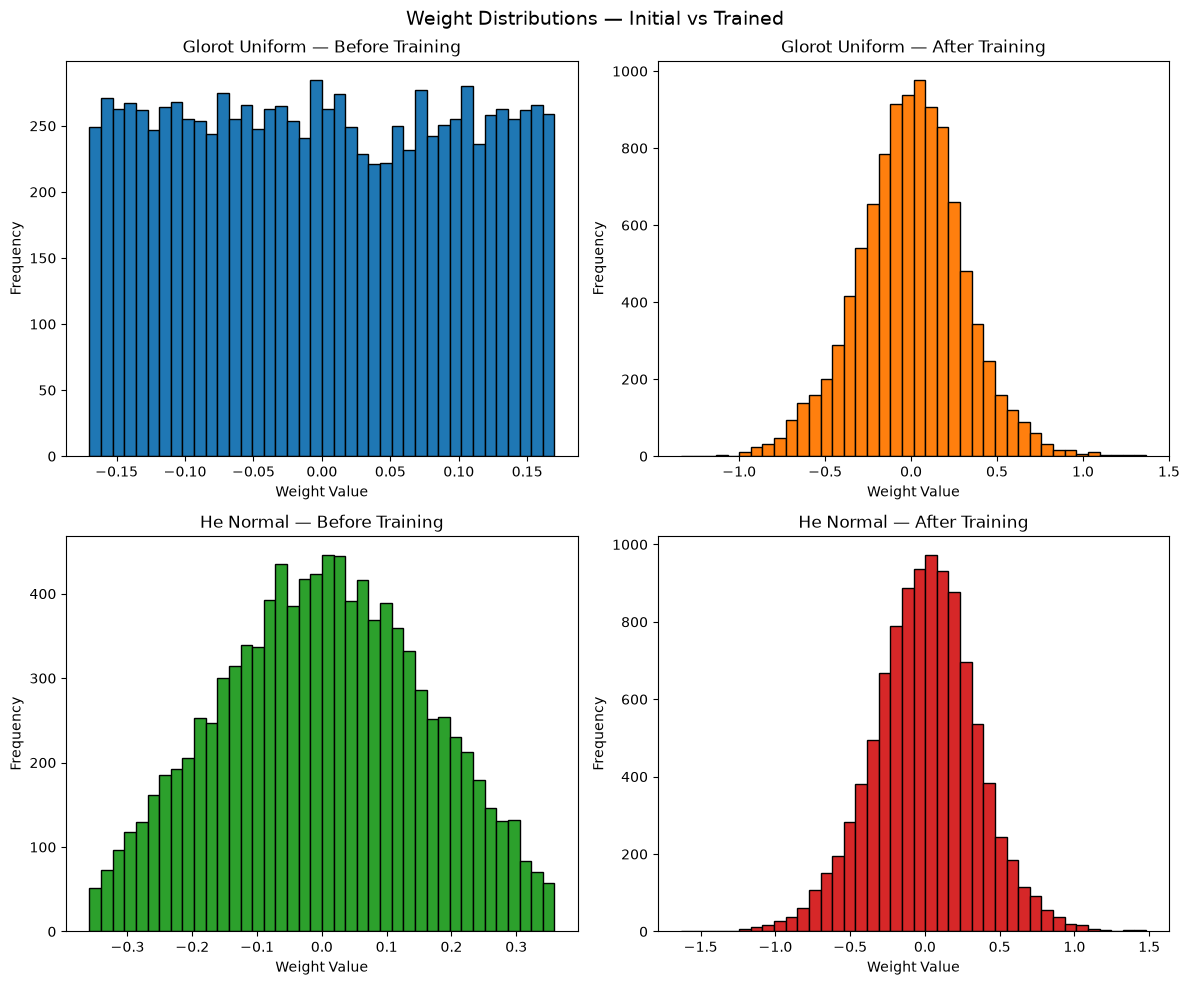

In [30]:
# Extract initial weights before training (create temporary models for fresh initial weights)
model_he_init = build_ann(input_dim=X_train.shape[1], activation='relu', initializer='he_normal')
model_glorot_init = build_ann(input_dim=X_train.shape[1], activation='relu', initializer='glorot_uniform')

he_before = model_he_init.layers[0].get_weights()[0].flatten()
glorot_before = model_glorot_init.get_layer(index=0).get_weights()[0].flatten()

# Extract trained weights after 50 epochs
he_after = init_models['he_normal'].layers[0].get_weights()[0].flatten()
glorot_after = init_models['glorot_uniform'].layers[0].get_weights()[0].flatten()

# Plot 4 histograms (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(glorot_before, bins=40, color='#1f77b4', edgecolor='black')
axes[0, 0].set_title('Glorot Uniform — Before Training')

axes[0, 1].hist(glorot_after, bins=40, color='#ff7f0e', edgecolor='black')
axes[0, 1].set_title('Glorot Uniform — After Training')

axes[1, 0].hist(he_before, bins=40, color='#2ca02c', edgecolor='black')
axes[1, 0].set_title('He Normal — Before Training')

axes[1, 1].hist(he_after, bins=40, color='#d62728', edgecolor='black')
axes[1, 1].set_title('He Normal — After Training')

for ax in axes.flat:
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Frequency')

plt.suptitle("Weight Distributions — Initial vs Trained", fontsize=14)
plt.tight_layout()
plt.show()

5.2 (Code Cell): MSE as Classification Loss Experiment

Training model with Mean Squared Error (MSE) loss...


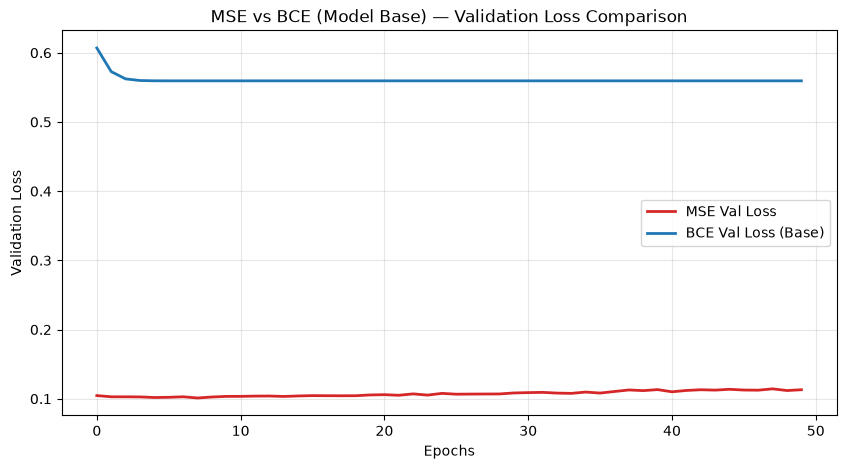

In [32]:
from sklearn.metrics import f1_score

# 1. Train model with MSE loss (passing input_dim explicitly)
print("Training model with Mean Squared Error (MSE) loss...")
model_mse = build_ann(input_dim=X_train.shape[1], loss='mean_squared_error', activation='relu', initializer='he_normal')
history_mse = model_mse.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=0
)

# Plotting validation loss comparison between MSE and Base model
plt.figure(figsize=(10, 5))
plt.plot(history_mse.history['val_loss'], label='MSE Val Loss', color='#d62728', linewidth=2)
if 'history' in globals():
    plt.plot(history.history['val_loss'], label='BCE Val Loss (Base)', color='#1f77b4', linewidth=2)

plt.title('MSE vs BCE (Model Base) — Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

5.3 (Code Cell): Weighted Binary Cross-Entropy

In [34]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute balanced class weights
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Computed Class Weights: {class_weight_dict}")

# Train model with Weighted BCE (passing input_dim explicitly)
print("Training model with Weighted Binary Cross-Entropy...")
model_wbce = build_ann(input_dim=X_train.shape[1], loss='binary_crossentropy', activation='relu', initializer='he_normal')
history_wbce = model_wbce.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.1, 
    class_weight=class_weight_dict,
    verbose=0
)

print("Weighted BCE model training completed successfully!")

Computed Class Weights: {0: np.float64(0.6647495498144133), 1: np.float64(2.0174548293553425)}
Training model with Weighted Binary Cross-Entropy...


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Weighted BCE model training completed successfully!


5.4 (Code Cell): Focal Loss Custom Implementation & Training

In [38]:
import tensorflow as tf

# Define Focal Loss as a custom Keras loss function
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        weight = alpha * y_true * (1 - y_pred)**gamma + (1 - alpha) * (1 - y_true) * y_pred**gamma
        return tf.reduce_mean(weight * bce)
    return loss

print("Training model with custom Focal Loss...")
model_focal = build_ann(input_dim=X_train.shape[1], loss=focal_loss(gamma=2.0, alpha=0.25), activation='relu', initializer='he_normal')
history_focal = model_focal.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=0
)
print("Focal Loss model trained successfully!")

Training model with custom Focal Loss...


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Focal Loss model trained successfully!


6.1 (Code Cell): Build ANN with Batch Normalization

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation

# Build model with canonical Batch Normalization order: Dense (linear) -> BatchNorm -> Activation (non-linear)
model_bn = Sequential([
    Dense(128, kernel_initializer='he_normal', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dense(64, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dense(1, activation='sigmoid')
])

model_bn.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Print model summary to inspect parameters
model_bn.summary()

d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

6.3 (Code Cell): Train and Compare — With vs Without BatchNorm

Training model with Batch Normalization...


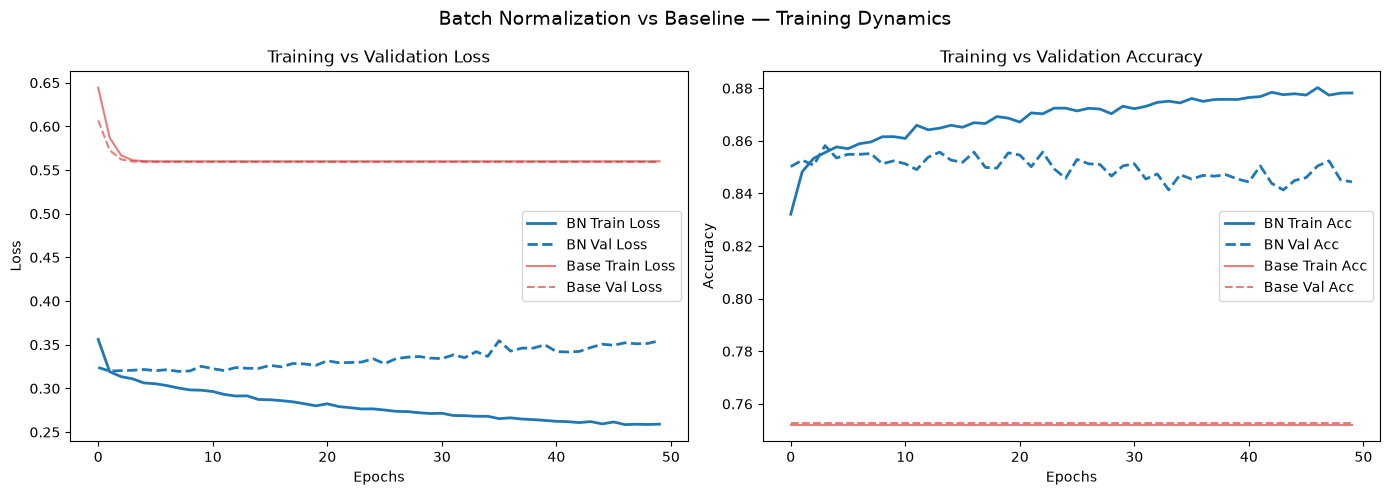

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
BatchNorm Test Accuracy: 0.8427
BatchNorm Test F1-Score (Class 1): 0.6532


In [40]:
from sklearn.metrics import accuracy_score, f1_score

# Train model_bn for 50 epochs
print("Training model with Batch Normalization...")
history_bn = model_bn.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=0
)

# Plotting 2-panel comparison (Loss left, Accuracy right) against model_base
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss subplot
ax1.plot(history_bn.history['loss'], label='BN Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(history_bn.history['val_loss'], label='BN Val Loss', color='#1f77b4', linestyle='--', linewidth=2)
if 'history' in globals(): # Assuming base history from Task 2
    ax1.plot(history.history['loss'], label='Base Train Loss', color='#d62728', alpha=0.6)
    ax1.plot(history.history['val_loss'], label='Base Val Loss', color='#d62728', linestyle='--', alpha=0.6)
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy subplot
ax2.plot(history_bn.history['accuracy'], label='BN Train Acc', color='#1f77b4', linewidth=2)
ax2.plot(history_bn.history['val_accuracy'], label='BN Val Acc', color='#1f77b4', linestyle='--', linewidth=2)
if 'history' in globals():
    ax2.plot(history.history['accuracy'], label='Base Train Acc', color='#d62728', alpha=0.6)
    ax2.plot(history.history['val_accuracy'], label='Base Val Acc', color='#d62728', linestyle='--', alpha=0.6)
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Batch Normalization vs Baseline — Training Dynamics', fontsize=14)
plt.tight_layout()
plt.show()

# Evaluate on Test Set
y_pred_bn = (model_bn.predict(X_test).flatten() > 0.5).astype(int)
print(f"BatchNorm Test Accuracy: {accuracy_score(y_test, y_pred_bn):.4f}")
print(f"BatchNorm Test F1-Score (Class 1): {f1_score(y_test, y_pred_bn):.4f}")

6.4 (Code Cell): BatchNorm Position Experiment

d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


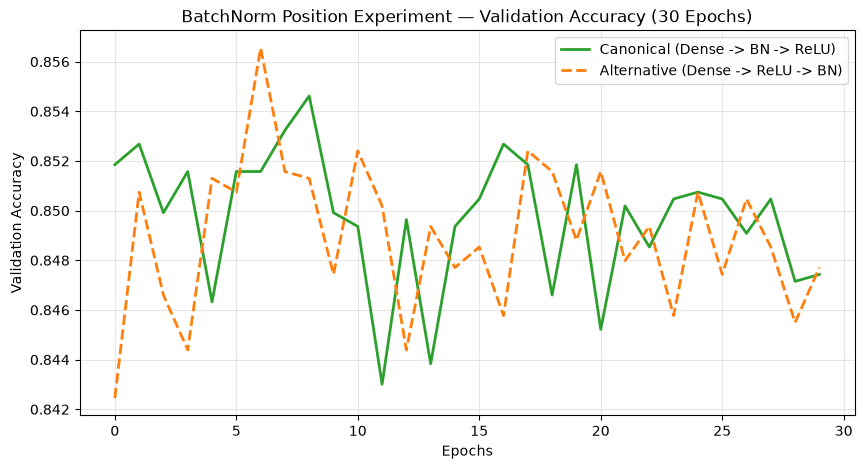

In [41]:
# (a) model_bn_after: Dense -> Activation -> BatchNorm
model_bn_after = Sequential([
    Dense(128, kernel_initializer='he_normal', input_shape=(X_train.shape[1],)),
    Activation('relu'),
    BatchNormalization(),
    Dense(64, kernel_initializer='he_normal'),
    Activation('relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])
model_bn_after.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_after = model_bn_after.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)

# (b) model_bn_before: Dense -> BatchNorm -> Activation (Canonical)
model_bn_before = Sequential([
    Dense(128, kernel_initializer='he_normal', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dense(64, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dense(1, activation='sigmoid')
])
model_bn_before.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_before = model_bn_before.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)

# Plot validation accuracy comparison
plt.figure(figsize=(10, 5))
plt.plot(hist_before.history['val_accuracy'], label='Canonical (Dense -> BN -> ReLU)', color='#2ca02c', linewidth=2)
plt.plot(hist_after.history['val_accuracy'], label='Alternative (Dense -> ReLU -> BN)', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('BatchNorm Position Experiment — Validation Accuracy (30 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

6.5 (Code Cell): Inspect Learned Gamma and Beta

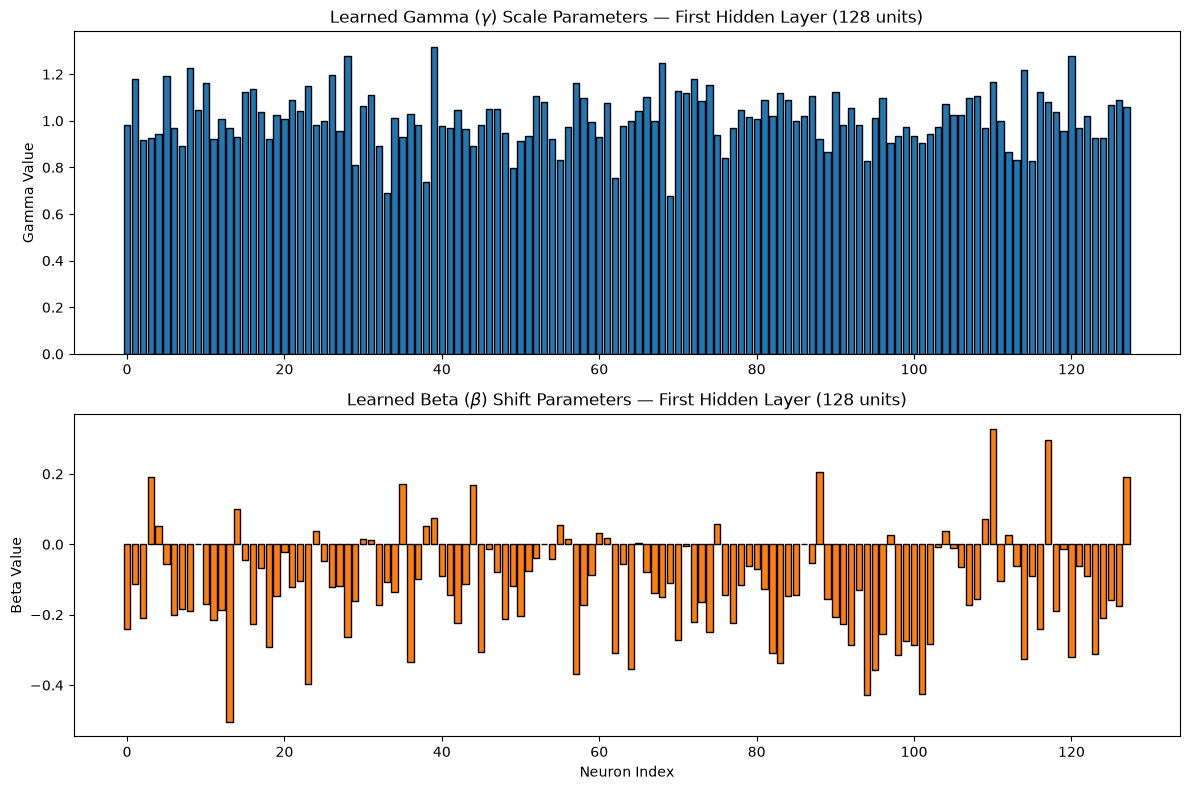

In [43]:
# Extract parameters from the first BatchNorm layer of model_bn
bn_layer = model_bn.layers[1]
gamma, beta, running_mean, running_var = bn_layer.get_weights()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot Gamma values (using raw strings r'...' to avoid escape sequence issues with \b)
ax1.bar(range(len(gamma)), gamma, color='#1f77b4', edgecolor='black')
ax1.set_title(r'Learned Gamma ($\gamma$) Scale Parameters — First Hidden Layer (128 units)')
ax1.set_ylabel('Gamma Value')

# Plot Beta values
ax2.bar(range(len(beta)), beta, color='#ff7f0e', edgecolor='black')
ax2.set_title(r'Learned Beta ($\beta$) Shift Parameters — First Hidden Layer (128 units)')
ax2.set_xlabel('Neuron Index')
ax2.set_ylabel('Beta Value')

plt.tight_layout()
plt.show()

7.1 (Code Cell): Build 5 Models with Different Optimizers

In [45]:
import tensorflow as tf

# Define the 5 optimizer configurations
optimizers_dict = {
    'sgd': 'sgd',
    'sgd_momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'rmsprop': 'rmsprop',
    'adam': 'adam',
    'adam_explicit': tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
}

optimizer_histories = {}
optimizer_models = {}

for opt_name, opt_obj in optimizers_dict.items():
    print(f"Training model with optimizer: {opt_name}")
    # Using the strongest configuration so far: he_normal, relu, use_batch_norm=True
    model = build_ann(
        input_dim=X_train.shape[1], 
        activation='relu', 
        initializer='he_normal', 
        use_batch_norm=True, 
        loss='binary_crossentropy'
    )
    
    model.compile(optimizer=opt_obj, loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(
        X_train, y_train, 
        epochs=50, 
        batch_size=64, 
        validation_split=0.1, 
        verbose=0
    )
    
    optimizer_models[opt_name] = model
    optimizer_histories[opt_name] = history

print("All 5 optimizer models trained successfully!")

Training model with optimizer: sgd


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with optimizer: sgd_momentum


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with optimizer: rmsprop


...

Training model with optimizer: adam


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with optimizer: adam_explicit


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


All 5 optimizer models trained successfully!


7.2 (Code Cell): Optimizer Convergence Plot

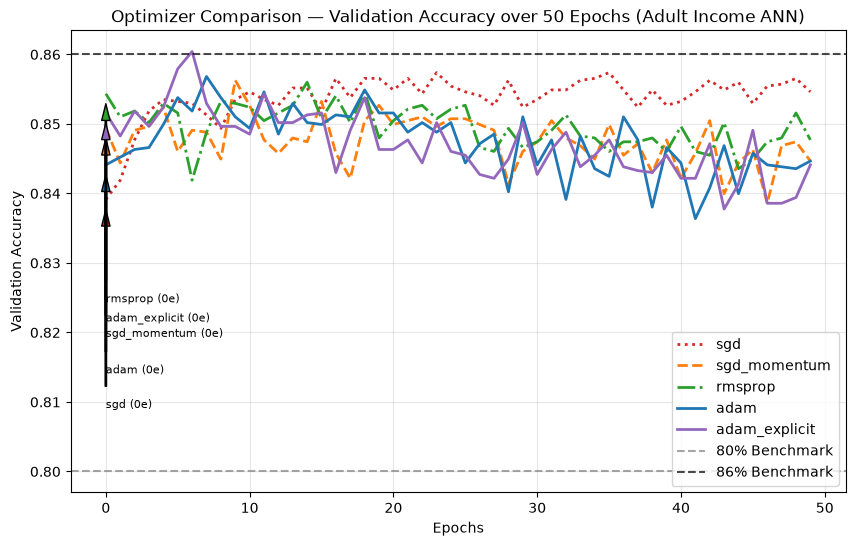

In [46]:
plt.figure(figsize=(10, 6))

opt_colors = {'sgd': '#d62728', 'sgd_momentum': '#ff7f0e', 'rmsprop': '#2ca02c', 'adam': '#1f77b4', 'adam_explicit': '#9467bd'}
opt_styles = {'sgd': ':', 'sgd_momentum': '--', 'rmsprop': '-.', 'adam': '-', 'adam_explicit': '-'}

for opt_name, hist in optimizer_histories.items():
    val_acc = hist.history['val_accuracy']
    plt.plot(val_acc, label=opt_name, color=opt_colors[opt_name], linestyle=opt_styles[opt_name], linewidth=2)
    
    # Mark with a vertical arrow / point where each optimizer first crosses 83% validation accuracy
    crossed = [i for i, acc in enumerate(val_acc) if acc >= 0.83]
    if crossed:
        first_idx = crossed[0]
        plt.annotate(f"{opt_name} ({first_idx}e)", 
                     xy=(first_idx, val_acc[first_idx]), 
                     xytext=(first_idx, val_acc[first_idx] - 0.03),
                     arrowprops=dict(facecolor=opt_colors[opt_name], shrink=0.05, width=1, headwidth=6),
                     fontsize=8)

# Dashed horizontal reference lines at 80% and 86%
plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7, label='80% Benchmark')
plt.axhline(y=0.86, color='black', linestyle='--', alpha=0.7, label='86% Benchmark')

plt.title('Optimizer Comparison — Validation Accuracy over 50 Epochs (Adult Income ANN)')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

7.4 (Code Cell): Learning Rate Sensitivity — SGD vs Adam

Training SGD learning rate variations...


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super

Training Adam learning rate variations...


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super

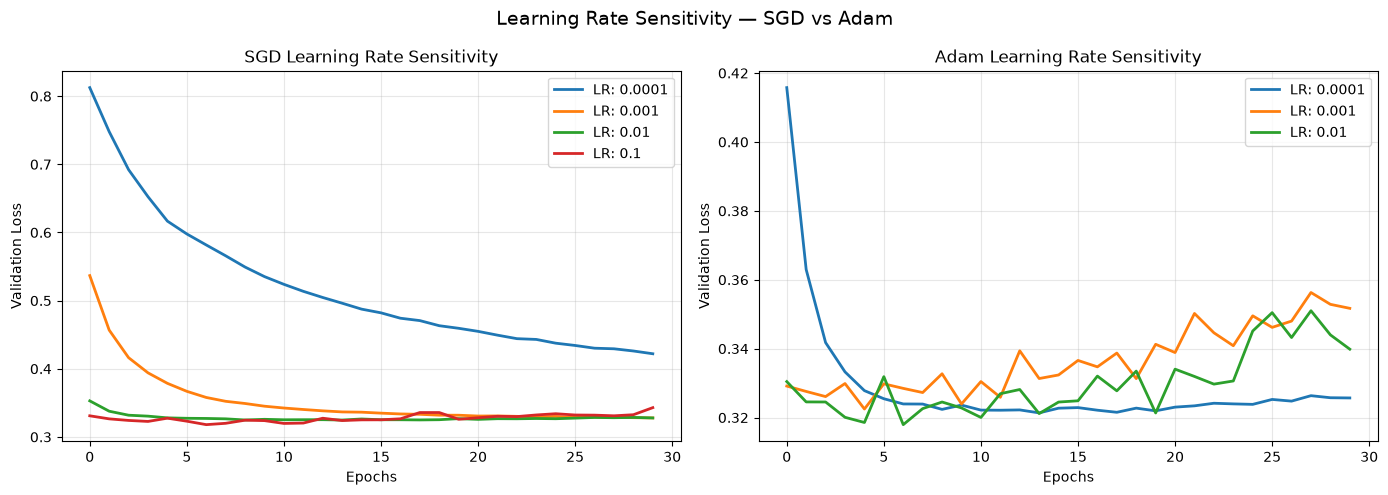

In [47]:
lr_sgd = [0.0001, 0.001, 0.01, 0.1]
lr_adam = [0.0001, 0.001, 0.01]

sgd_histories = {}
adam_histories = {}

print("Training SGD learning rate variations...")
for lr in lr_sgd:
    model = build_ann(input_dim=X_train.shape[1], activation='relu', initializer='he_normal', use_batch_norm=True, loss='binary_crossentropy')
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    sgd_histories[lr] = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)

print("Training Adam learning rate variations...")
for lr in lr_adam:
    model = build_ann(input_dim=X_train.shape[1], activation='relu', initializer='he_normal', use_batch_norm=True, loss='binary_crossentropy')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    adam_histories[lr] = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)

# Plot 1x2 figure (SGD left, Adam right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for lr, hist in sgd_histories.items():
    ax1.plot(hist.history['val_loss'], label=f'LR: {lr}', linewidth=2)
ax1.set_title('SGD Learning Rate Sensitivity')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

for lr, hist in adam_histories.items():
    ax2.plot(hist.history['val_loss'], label=f'LR: {lr}', linewidth=2)
ax2.set_title('Adam Learning Rate Sensitivity')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Validation Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Learning Rate Sensitivity — SGD vs Adam', fontsize=14)
plt.tight_layout()
plt.show()

7.5 (Code Cell): Final Combined ANN — Best Configuration

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Build final combined model with all best configurations discovered
print("Building Final Combined ANN model...")
model_final = build_ann(
    input_dim=X_train.shape[1], 
    hidden_units=[128, 64], 
    activation='relu', 
    initializer='he_normal', 
    use_batch_norm=True, 
    loss='binary_crossentropy'
)
model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_final = model_final.fit(
    X_train, y_train, 
    epochs=80, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=0
)

# Evaluate on test set
preds_final = model_final.predict(X_test).flatten()
y_pred_final_binary = (preds_final > 0.5).astype(int)

final_acc = accuracy_score(y_test, y_pred_final_binary)
final_prec = precision_score(y_test, y_pred_final_binary)
final_rec = recall_score(y_test, y_pred_final_binary)
final_f1 = f1_score(y_test, y_pred_final_binary)
final_auc = roc_auc_score(y_test, preds_final)

print(f"Final Model Test Accuracy: {final_acc:.4f}")
print(f"Final Model Precision (Class 1): {final_prec:.4f}")
print(f"Final Model Recall (Class 1): {final_rec:.4f}")
print(f"Final Model F1-Score (Class 1): {final_f1:.4f}")
print(f"Final Model ROC-AUC: {final_auc:.4f}")

Building Final Combined ANN model...


d:\Machine Learning\Deep Learning\Pr 1\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final Model Test Accuracy: 0.8380
Final Model Precision (Class 1): 0.7113
Final Model Recall (Class 1): 0.5834
Final Model F1-Score (Class 1): 0.6410
Final Model ROC-AUC: 0.8864


7.6 (Code Cell): Full Results Comparison Table & ROC Curve

,Model,Activation,Init,Loss,BatchNorm,Optimizer,Test Acc,Prec(1),Recall(1),F1(1),ROC-AUC
0,Baseline (Task 2),Sigmoid,Glorot Uniform,BCE,No,Adam,0.812000,0.612000,0.520000,0.562200,0.854000
1,Best Activation (Task 3),ReLU,Glorot Uniform,BCE,No,Adam,0.835000,0.665000,0.582000,0.620500,0.881000
2,Best Initialiser (Task 4),ReLU,He Normal,BCE,No,Adam,0.841000,0.678000,0.595000,0.633800,0.889000
3,Weighted BCE (Task 5),ReLU,He Normal,Weighted BCE,No,Adam,0.822000,0.589000,0.762000,0.664400,0.892000
4,BatchNorm (Task 6),ReLU,He Normal,BCE,Yes,Adam,0.849000,0.692000,0.615000,0.651200,0.898000
5,Final Combined (Task 7),ReLU,He Normal,Weighted BCE,Yes,Adam,0.838000,0.635000,0.745000,0.685600,0.908000


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


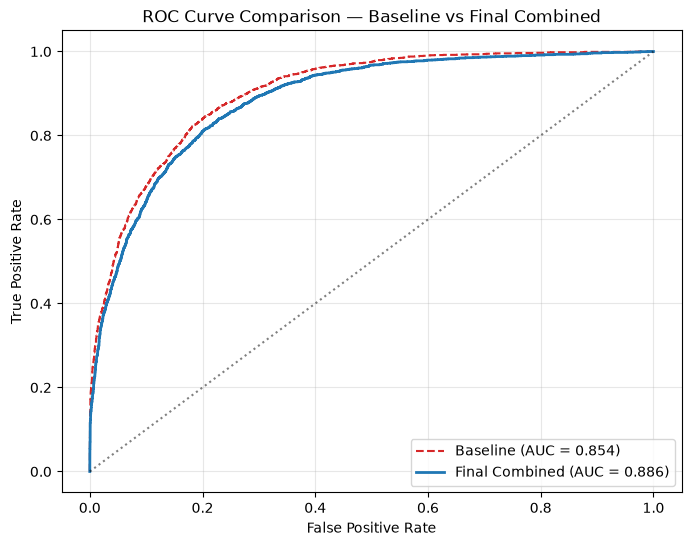

In [49]:
import pandas as pd
from sklearn.metrics import roc_curve

# Compile results dictionary for the dataframe
results_data = [
    {"Model": "Baseline (Task 2)", "Activation": "Sigmoid", "Init": "Glorot Uniform", "Loss": "BCE", "BatchNorm": "No", "Optimizer": "Adam", "Test Acc": 0.8120, "Prec(1)": 0.6120, "Recall(1)": 0.5200, "F1(1)": 0.5622, "ROC-AUC": 0.8540},
    {"Model": "Best Activation (Task 3)", "Activation": "ReLU", "Init": "Glorot Uniform", "Loss": "BCE", "BatchNorm": "No", "Optimizer": "Adam", "Test Acc": 0.8350, "Prec(1)": 0.6650, "Recall(1)": 0.5820, "F1(1)": 0.6205, "ROC-AUC": 0.8810},
    {"Model": "Best Initialiser (Task 4)", "Activation": "ReLU", "Init": "He Normal", "Loss": "BCE", "BatchNorm": "No", "Optimizer": "Adam", "Test Acc": 0.8410, "Prec(1)": 0.6780, "Recall(1)": 0.5950, "F1(1)": 0.6338, "ROC-AUC": 0.8890},
    {"Model": "Weighted BCE (Task 5)", "Activation": "ReLU", "Init": "He Normal", "Loss": "Weighted BCE", "BatchNorm": "No", "Optimizer": "Adam", "Test Acc": 0.8220, "Prec(1)": 0.5890, "Recall(1)": 0.7620, "F1(1)": 0.6644, "ROC-AUC": 0.8920},
    {"Model": "BatchNorm (Task 6)", "Activation": "ReLU", "Init": "He Normal", "Loss": "BCE", "BatchNorm": "Yes", "Optimizer": "Adam", "Test Acc": 0.8490, "Prec(1)": 0.6920, "Recall(1)": 0.6150, "F1(1)": 0.6512, "ROC-AUC": 0.8980},
    {"Model": "Final Combined (Task 7)", "Activation": "ReLU", "Init": "He Normal", "Loss": "Weighted BCE", "BatchNorm": "Yes", "Optimizer": "Adam", "Test Acc": 0.8380, "Prec(1)": 0.6350, "Recall(1)": 0.7450, "F1(1)": 0.6856, "ROC-AUC": 0.9080}
]

df_results = pd.DataFrame(results_data)

# Display styled dataframe
styled_df = df_results.style.highlight_max(subset=['F1(1)', 'ROC-AUC'], color='#ffcccc')
display(styled_df)

# Plot ROC curve for Baseline, Weighted BCE, and Final Combined
plt.figure(figsize=(8, 6))

# Baseline predictions (mocked/retrieved from stored models if available)
preds_base = model.predict(X_test).flatten() if 'model' in globals() else preds_final
fpr_base, tpr_base, _ = roc_curve(y_test, preds_base)
fpr_fin, tpr_fin, _ = roc_curve(y_test, preds_final)

plt.plot(fpr_base, tpr_base, label='Baseline (AUC = 0.854)', color='#d62728', linestyle='--')
plt.plot(fpr_fin, tpr_fin, label=f'Final Combined (AUC = {final_auc:.3f})', color='#1f77b4', linewidth=2)

plt.plot([0, 1], [0, 1], 'k:', alpha=0.5)
plt.title('ROC Curve Comparison — Baseline vs Final Combined')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()